Import Libraries

In [2]:
from google.colab import drive
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # specific for Colab progress bars
import random
import itertools



Configuration & Paths


In [3]:
# --- CONFIGURATION ---
# Path where your raw dataset is located (containing 001, 002... folders)
RAW_DATA_PATH = "/content/drive/MyDrive/sign_dataset"

# Path where the processed .npy files will be saved
OUTPUT_PATH = "/content/drive/MyDrive/Processed_GPDS_CEDAR"

# Target Image Size (Standard for models like ResNet/VGG)
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Create output directory if it doesn't exist
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)
    print(f"Created output directory: {OUTPUT_PATH}")
else:
    print(f"Output directory already exists: {OUTPUT_PATH}")

Created output directory: /content/drive/MyDrive/Processed_GPDS_CEDAR


Robust Preprocessing Function

In [4]:
def preprocess_signature(img_path, img_h, img_w):
    """
    1. Reads image in Grayscale.
    2. Binarizes (Otsu) and Inverts (Ink=White, Background=Black).
    3. Resizes while maintaining aspect ratio (Padding).
    """
    try:
        # 1. Read Image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None

        # 2. Binarization & Inversion
        # OTSU automatically finds the best threshold to separate ink from paper
        _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # 3. Aspect Ratio Preserving Resize
        h, w = img.shape
        scale = min(img_h / h, img_w / w)
        new_h, new_w = int(h * scale), int(w * scale)

        resized_img = cv2.resize(img, (new_w, new_h))

        # Create blank canvas (black background)
        canvas = np.zeros((img_h, img_w), dtype=np.uint8)

        # Calculate centering offsets
        y_offset = (img_h - new_h) // 2
        x_offset = (img_w - new_w) // 2

        # Place image in center
        canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized_img

        # Reshape to (H, W, 1) for CNN input
        canvas = np.expand_dims(canvas, axis=-1)

        return canvas

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

print("Preprocessing function defined.")

Preprocessing function defined.


Main Processing Loop

In [5]:
X_data = []
y_data = []      # 1 = Genuine, 0 = Forged
user_ids = []    # To keep track of which user the signature belongs to

# Get sorted list of user folders
if os.path.exists(RAW_DATA_PATH):
    user_folders = sorted(os.listdir(RAW_DATA_PATH))
    # Filter for directories only
    user_folders = [f for f in user_folders if os.path.isdir(os.path.join(RAW_DATA_PATH, f))]
    print(f"Found {len(user_folders)} users. Starting processing...")
else:
    print(f"Error: Path {RAW_DATA_PATH} not found.")
    user_folders = []

# --- PROCESSING LOOP ---
total_images = 0
pbar = tqdm(user_folders, desc="Processing Users")

for user_folder in pbar:
    user_path = os.path.join(RAW_DATA_PATH, user_folder)

    # 1. Process Genuine
    gen_path = os.path.join(user_path, 'genuine')
    if os.path.exists(gen_path):
        for img_name in os.listdir(gen_path):
            full_path = os.path.join(gen_path, img_name)
            processed_img = preprocess_signature(full_path, IMG_HEIGHT, IMG_WIDTH)

            if processed_img is not None:
                X_data.append(processed_img)
                y_data.append(1)
                user_ids.append(user_folder)
                total_images += 1

    # 2. Process Forged
    forg_path = os.path.join(user_path, 'forged')
    if os.path.exists(forg_path):
        for img_name in os.listdir(forg_path):
            full_path = os.path.join(forg_path, img_name)
            processed_img = preprocess_signature(full_path, IMG_HEIGHT, IMG_WIDTH)

            if processed_img is not None:
                X_data.append(processed_img)
                y_data.append(0)
                user_ids.append(user_folder)
                total_images += 1

    # Update progress bar description with total count
    pbar.set_postfix({'Total Images': total_images})

# Save as uint8 (0-255) to reduce file size on Drive.
# You will normalize to 0-1 (float32) during training.
X_data = np.array(X_data, dtype=np.uint8)
y_data = np.array(y_data, dtype=np.int8)
user_ids = np.array(user_ids)

print(f"\nProcessing Complete.")
print(f"Total Images: {X_data.shape[0]}")
print(f"Data Shape: {X_data.shape}")

Found 205 users. Starting processing...


Processing Users:   0%|          | 0/205 [00:00<?, ?it/s]


Processing Complete.
Total Images: 7451
Data Shape: (7451, 224, 224, 1)


Auto-Upload Raw Data to Drive

In [6]:
print(f"Saving image arrays to: {OUTPUT_PATH} ...")

np.save(os.path.join(OUTPUT_PATH, "X_signatures.npy"), X_data)
np.save(os.path.join(OUTPUT_PATH, "y_labels.npy"), y_data)
np.save(os.path.join(OUTPUT_PATH, "user_ids.npy"), user_ids)

print("SUCCESS: Raw image data uploaded to Drive.")

Saving image arrays to: /content/drive/MyDrive/Processed_GPDS_CEDAR ...
SUCCESS: Raw image data uploaded to Drive.


Visual Sanity Check

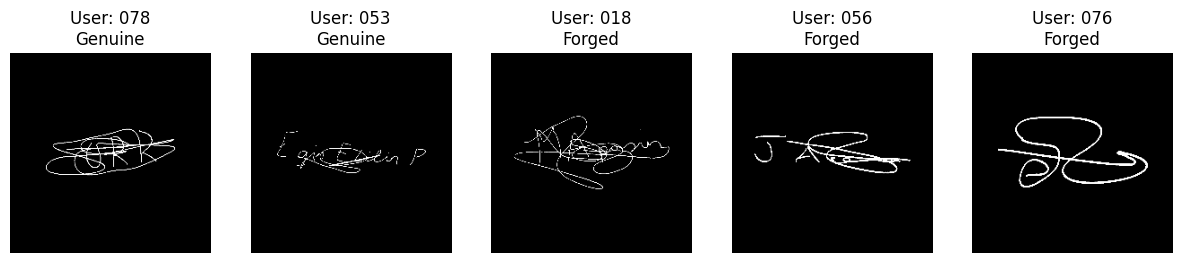

In [7]:
def show_samples(X, y, uids, count=5):
    plt.figure(figsize=(15, 3))
    indices = random.sample(range(len(X)), count)

    for i, idx in enumerate(indices):
        plt.subplot(1, count, i+1)
        plt.imshow(X[idx].squeeze(), cmap='gray')
        label = "Genuine" if y[idx] == 1 else "Forged"
        plt.title(f"User: {uids[idx]}\n{label}")
        plt.axis('off')
    plt.show()

show_samples(X_data, y_data, user_ids)

Generate Siamese Pairs
This creates the actual training data structure for verification models.

Positive Pair: (Genuine, Genuine)

Negative Pair: (Genuine, Forged)

In [8]:
# 1. Index Mapping
user_index_map = {}
for i, (uid, label) in enumerate(zip(user_ids, y_data)):
    if uid not in user_index_map:
        user_index_map[uid] = {'genuine': [], 'forged': []}
    key = 'genuine' if label == 1 else 'forged'
    user_index_map[uid][key].append(i)

# 2. Pair Generation
def create_pairs(user_map):
    pairs = []
    labels = []

    print("Generating pairs...")

    for uid in tqdm(user_map.keys()):
        gens = user_map[uid]['genuine']
        forgs = user_map[uid]['forged']

        # --- Positive Pairs (Gen + Gen) ---
        # Combinations of all genuine signatures
        pos_combs = list(itertools.combinations(gens, 2))

        for p in pos_combs:
            pairs.append(list(p))
            labels.append(1.0) # 1 = Same

        # --- Negative Pairs (Gen + Forg) ---
        # Pair genuine with random forgeries to balance the dataset
        num_pos = len(pos_combs)
        neg_combs = list(itertools.product(gens, forgs))

        # Downsample negatives to match positives (Balance is crucial)
        if len(neg_combs) > num_pos:
            neg_combs = random.sample(neg_combs, num_pos)

        for p in neg_combs:
            pairs.append(list(p))
            labels.append(0.0) # 0 = Different

    return np.array(pairs), np.array(labels, dtype=np.float32)

pairs, pair_labels = create_pairs(user_index_map)

print(f"Total Pairs: {len(pairs)}")

Generating pairs...


  0%|          | 0/205 [00:00<?, ?it/s]

Total Pairs: 66392


Save Pair Data to Drive

In [9]:
print(f"Saving pair indices to: {OUTPUT_PATH} ...")

np.save(os.path.join(OUTPUT_PATH, "pairs_indices.npy"), pairs)
np.save(os.path.join(OUTPUT_PATH, "pairs_labels.npy"), pair_labels)

print("SUCCESS: Pair data uploaded.")
print("Preprocessing Complete. You can now use these .npy files for model training.")

Saving pair indices to: /content/drive/MyDrive/Processed_GPDS_CEDAR ...
SUCCESS: Pair data uploaded.
Preprocessing Complete. You can now use these .npy files for model training.
